In [23]:
%pip install --trusted-host https://mirror-pypi.runflare.com -i https://mirror-pypi.runflare.com/simple/ opencv-python

Looking in indexes: https://mirror-pypi.runflare.com/simple/
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 1.4 MB/s eta 0:00:29
    --------------------------------------- 0.5/40.2 MB 1.4 MB/s eta 0:00:29
    --------------------------------------- 0.8/40.2 MB 1.2 MB/s eta 0:00:33
   - -------------------------------------- 1.0/40.2 MB 1.3 MB/s eta 0:00:32
   - -------------------------------------- 1.6/40.2 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.8/40.2 MB 1.3 MB/s eta 0:00:30
   -- ------------------------------------- 2.1/40.2 MB 1.3 MB/s eta 0:00:29
   -- ------------------------------------- 2.4/40.2 MB 1.3 MB/s eta 0:00:30
   -- ------------------------------------- 2.6/40.2 MB 1.3 MB/s eta 0:00:29
   -- ------------------------------------- 2.9/40.2 MB 1.3 MB/s eta 0:00:29
   --- ----------------------

In [26]:
import os
import tarfile
import glob

In [27]:
path = r'data\flowers.tgz'

with tarfile.open(path, 'r:gz') as tar:
    tar.extractall('train_data')
    tar.close()

C:\Users\USER\AppData\Local\Temp\ipykernel_6300\253416039.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('train_data')


In [30]:
image_paths = sorted(glob.glob('train_data\jpg\*.jpg'))
image_paths

['train_data\\jpg\\image_0001.jpg',
 'train_data\\jpg\\image_0002.jpg',
 'train_data\\jpg\\image_0003.jpg',
 'train_data\\jpg\\image_0004.jpg',
 'train_data\\jpg\\image_0005.jpg',
 'train_data\\jpg\\image_0006.jpg',
 'train_data\\jpg\\image_0007.jpg',
 'train_data\\jpg\\image_0008.jpg',
 'train_data\\jpg\\image_0009.jpg',
 'train_data\\jpg\\image_0010.jpg',
 'train_data\\jpg\\image_0011.jpg',
 'train_data\\jpg\\image_0012.jpg',
 'train_data\\jpg\\image_0013.jpg',
 'train_data\\jpg\\image_0014.jpg',
 'train_data\\jpg\\image_0015.jpg',
 'train_data\\jpg\\image_0016.jpg',
 'train_data\\jpg\\image_0017.jpg',
 'train_data\\jpg\\image_0018.jpg',
 'train_data\\jpg\\image_0019.jpg',
 'train_data\\jpg\\image_0020.jpg',
 'train_data\\jpg\\image_0021.jpg',
 'train_data\\jpg\\image_0022.jpg',
 'train_data\\jpg\\image_0023.jpg',
 'train_data\\jpg\\image_0024.jpg',
 'train_data\\jpg\\image_0025.jpg',
 'train_data\\jpg\\image_0026.jpg',
 'train_data\\jpg\\image_0027.jpg',
 'train_data\\jpg\\image_002

In [32]:
class_names = [
    'Buttercup', 'ColtsFoot', 'Daffodil', 'Daisy', 'Dandelion', 'Fritillary', 'Iris', 'Pansy', 'Sunflower', 'Windflower',
    'Snowdrop', 'LilyValley', 'Bluebell', 'Crocus', 'Tigerlily', 'Tulip', 'Cowslip'
]
l = 0
i = 0
j = 80
for k in range(1, 18):
    os.makedirs('train_data/' + class_names[l])
    current_path = 'train_data/' + class_names[l] + '/'
    for index, image_path in enumerate(image_paths[i:j], start=1):
        original = image_path
        image_path = image_path.split('/')
        image_file_name = str(index) + '.jpg'
        os.rename(original, current_path + image_file_name)
    l += 1
    i += 80
    j += 80

In [33]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [46]:
img = cv2.imread(r'D:\Machin_learning\my_codes\train_data\Bluebell\1.jpg')
print(img.shape)

(500, 611, 3)


In [47]:
image_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

In [48]:
image = cv2.resize(img, (500, 500))
hist = cv2.calcHist([image], [0, 1, 2], None, [
                    8, 8, 8], [0, 256, 0, 256, 0, 256])
cv2.normalize(hist, hist)
image_histogram = hist.flatten()

In [49]:
hist = cv2.calcHist([image], [0], None, [256], [0, 256])

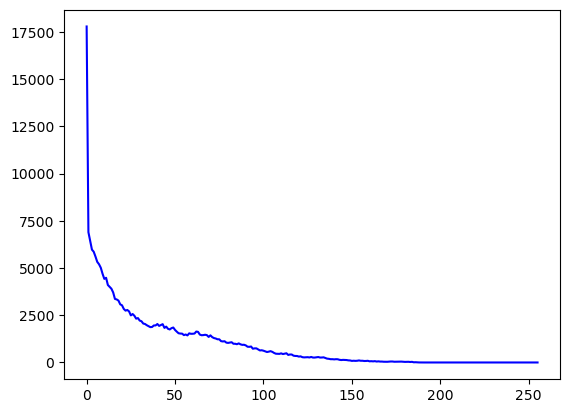

In [50]:
plt.plot(hist, color='blue')

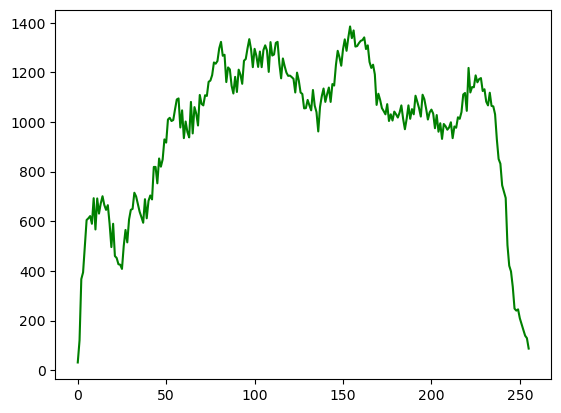

In [51]:
hist = cv2.calcHist([image], [1], None, [256], [0, 256])
plt.plot(hist, color='green')

0 b
1 g
2 r


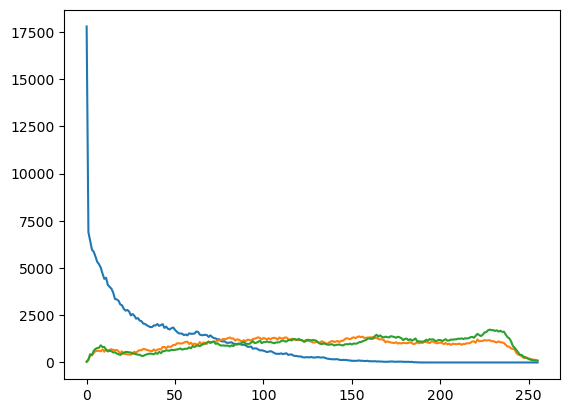

In [53]:
for channel, col in enumerate(('b', 'g', 'r')):
    print(channel, col)
    hist = cv2.calcHist([image], [channel], None, [256], [0, 256])
    plt.plot(hist)

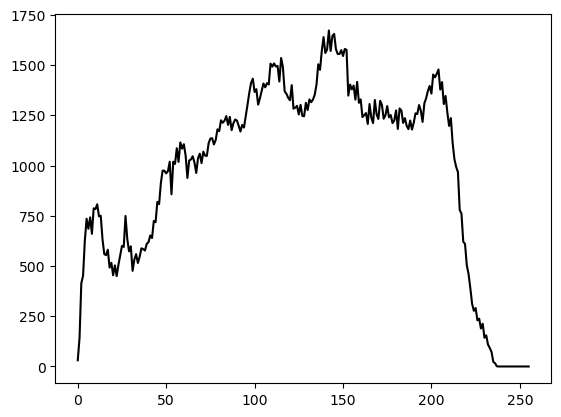

In [57]:
gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray_hist = cv2.calcHist([gray_img], [0], None, [256], [0, 256])
plt.Figure()

plt.plot(gray_hist, color='k')

In [2]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import numpy as np
import pandas as pd
import os
import cv2
import h5py
import pickle

In [25]:
train_labels = os.listdir('train_data/')
train_labels.sort()
train_labels = train_labels[:-1]
train_labels

['Bluebell',
 'Buttercup',
 'ColtsFoot',
 'Cowslip',
 'Crocus',
 'Daffodil',
 'Daisy',
 'Dandelion',
 'Fritillary',
 'Iris',
 'LilyValley',
 'Pansy',
 'Snowdrop',
 'Sunflower',
 'Tigerlily',
 'Tulip',
 'Windflower']

In [27]:
X = []
y = []

for label in train_labels:
    base = r"D:\Machin_learning\my_codes\train_data"
    dir = os.path.join(base, label)
    current_label = label
    for x in range(1, 81):
        file = os.path.join(dir, str(x) + '.jpg')
        image = cv2.imread(file)
        image = cv2.resize(image, (500, 500))
        image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([image_hsv], [0, 1, 2], None, [
                            8, 8, 8], [0, 256, 0, 256, 0, 256])
        cv2.normalize(hist, hist)
        histogram_features = hist.flatten()
        gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        hue_features = cv2.HuMoments(cv2.moments(gray_img)).flatten()
        current_features = np.hstack([histogram_features, hue_features])
        X.append(current_features)
        y.append(current_label)

In [30]:
le = LabelEncoder()
y = le.fit_transform(y)

In [31]:
mms = MinMaxScaler()
X = mms.fit_transform(X)

In [ ]:
h5_X = h5py.File('data/X.h5', 'w')

In [37]:

h5_X.create_dataset('features', data=np.array(X))

<HDF5 dataset "features": shape (1360, 519), type "<f8">

In [38]:
h5_y = h5py.File('data/y.h5', 'w')
h5_y.create_dataset('targets', data=np.array(y))

<HDF5 dataset "targets": shape (1360,), type "<i8">

In [39]:
h5_X.close()
h5_y.close()

In [40]:
import h5py
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [41]:
X = np.array(h5py.File(os.path.join('data', 'X.h5'), 'r')['features'])
y = np.array(h5py.File(os.path.join('data', 'y.h5'), 'r')['targets'])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=100)

In [52]:
rfc = RandomForestClassifier(n_estimators=400)
rfc.fit(X_train, y_train)

,n_estimators,400
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
y_pred = rfc.predict(X_test)

In [54]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.39      0.47      0.42        15
           1       0.37      0.64      0.47        11
           2       0.69      0.75      0.72        24
           3       0.68      0.75      0.71        20
           4       0.74      0.59      0.65        29
           5       0.47      0.35      0.40        20
           6       0.80      0.71      0.75        28
           7       0.62      0.76      0.68        21
           8       0.43      0.83      0.57        12
           9       0.83      0.91      0.87        11
          10       0.62      0.60      0.61        25
          11       0.23      0.50      0.31        10
          12       0.83      0.62      0.71        24
          13       1.00      0.84      0.91        19
          14       0.73      0.44      0.55        18
          15       0.73      0.53      0.62        30
          16       0.67      0.52      0.59        23

    accuracy              